# CTI Evaluation Hub

Runs and displays results for two separate evaluations:
- **NER** (`tools/eval_ner.py`): pass-1 entity extraction vs gold DNRTI labels
- **RE â€” oracle NER** (`tools/eval_re_gold.py`): pass-2 relation extraction with *gold* entity hints vs gold triples

The oracle-NER RE eval isolates relation extraction quality from NER errors,
matching the methodology used in the JE_BERT_CRF baseline.

In [1]:
import os, subprocess, json, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure we run from repo root
_nb = Path(__vsc_ipynb_file__).resolve().parent if "__vsc_ipynb_file__" in dir() else Path.cwd()
_repo = _nb.parent if _nb.name == "notebooks" else _nb
os.chdir(_repo)
print(f"Working directory: {os.getcwd()}")

MODEL   = "gemma3-cti-4b"
DATA    = "results/finetuning/data/test_dnrti.json"
URL     = "http://localhost:11434"
TIMEOUT = 300
LIMIT   = None   # set e.g. 10 for a quick smoke test

def _run(script, extra_args=None):
    cmd = [sys.executable, script,
           "--model", MODEL, "--data", DATA,
           "--url", URL, "--timeout", str(TIMEOUT)]
    if LIMIT:
        cmd += ["--limit", str(LIMIT)]
    if extra_args:
        cmd += extra_args
    r = subprocess.run(cmd, capture_output=True, text=True, cwd=str(_repo))
    print(r.stdout)
    if r.returncode != 0:
        print(r.stderr, file=sys.stderr)
    return r.returncode == 0

def _latest(pattern):
    files = sorted(Path("results/eval").glob(pattern))
    if not files:
        return {}
    print(f"Loaded: {files[-1].name}")
    return json.loads(files[-1].read_text())

Working directory: C:\CTI


## 1. NER Evaluation

In [2]:
_run("tools/eval_ner.py")

NER Evaluation
  model  : gemma3-cti-4b
  data   : results\finetuning\data\test_dnrti.json (707 docs)
  output : results\eval\ner_20260313-160323.json

  [50/707] running TP=156 FP=41 FN=45
  [100/707] running TP=297 FP=101 FN=81
  [150/707] running TP=452 FP=149 FN=128
  [200/707] running TP=587 FP=195 FN=173
  [250/707] running TP=732 FP=233 FN=213
  [300/707] running TP=879 FP=273 FN=259
  [350/707] running TP=1027 FP=332 FN=294
  [400/707] running TP=1173 FP=391 FN=335
  [450/707] running TP=1318 FP=443 FN=372
  [500/707] running TP=1460 FP=497 FN=411
  [550/707] running TP=1604 FP=552 FN=446
  [600/707] running TP=1746 FP=610 FN=496
  [650/707] running TP=1878 FP=674 FN=538
  [700/707] running TP=2022 FP=717 FN=582

NER RESULTS  (model: gemma3-cti-4b)
Docs evaluated : 704 / 707

MICRO  P=0.7383  R=0.7760  F1=0.7567
       TP=2037  FP=722  FN=588
MACRO  P=0.7548  R=0.7794  F1=0.7501

PER-TYPE:
  Type            P      R     F1    TP    FP    FN   Gold
  ----------------------------

True

In [3]:
ner = _latest("ner_*.json")

if ner:
    m, mm = ner["micro"], ner["macro"]
    print(f"MICRO  P={m['precision']:.4f}  R={m['recall']:.4f}  F1={m['f1']:.4f}  "
          f"TP={m['tp']}  FP={m['fp']}  FN={m['fn']}")
    print(f"MACRO  P={mm['precision']:.4f}  R={mm['recall']:.4f}  F1={mm['f1']:.4f}")
    print()

    rows = [{"Type": t, **s} for t, s in ner["per_type"].items()]
    df_ner = (pd.DataFrame(rows)
                .set_index("Type")
                .sort_values("f1", ascending=False)
                .rename(columns={"precision": "P", "recall": "R", "f1": "F1",
                                  "tp": "TP", "fp": "FP", "fn": "FN", "gold": "Gold"}))
    display(df_ner.style
            .format({"P": "{:.4f}", "R": "{:.4f}", "F1": "{:.4f}"})
            .background_gradient(subset=["F1"], cmap="RdYlGn"))

Loaded: ner_20260313-160323.json
MICRO  P=0.7383  R=0.7760  F1=0.7567  TP=2037  FP=722  FN=588
MACRO  P=0.7548  R=0.7794  F1=0.7501



,P,R,F1,TP,FP,FN,Gold
Type,,,,,,,
VULID,1.0000,1.0000,1.0000,37,0,0,37
HASH,1.0000,0.8889,0.9412,16,0,2,18
TIME,0.9315,0.9067,0.9189,136,10,14,150
DOM,0.8571,0.9231,0.8889,12,2,1,13
IP,0.8000,1.0000,0.8889,8,2,0,8
ENCR,0.8333,0.9091,0.8696,10,2,1,11
URL,0.7500,1.0000,0.8571,6,2,0,6
LOC,0.8537,0.8434,0.8485,140,24,26,166
APT,0.8528,0.8421,0.8474,336,58,63,399


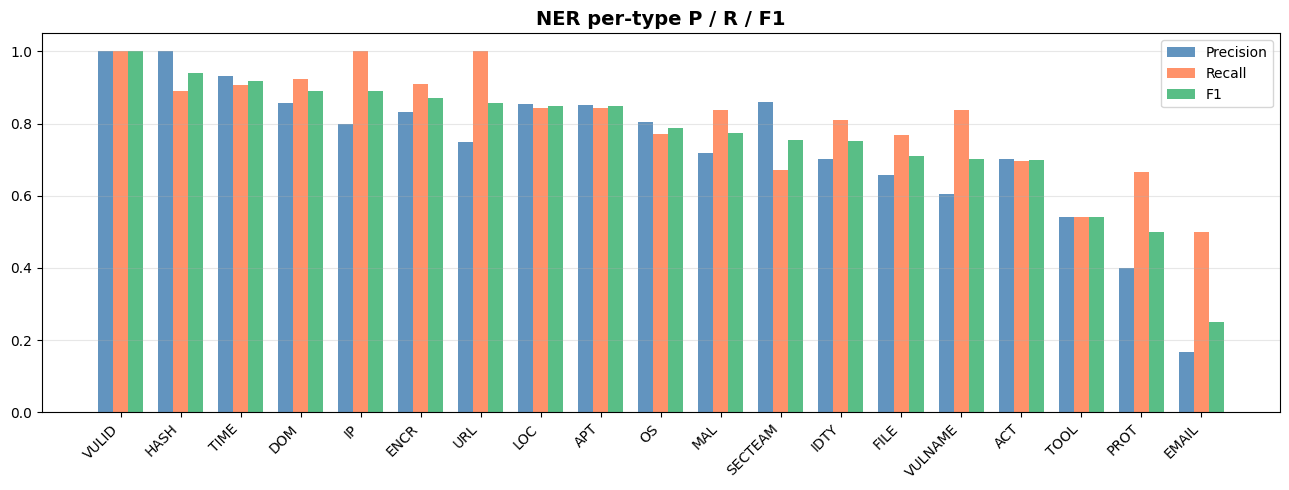

In [4]:
if ner:
    types = df_ner.index.tolist()
    x, w = np.arange(len(types)), 0.25
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - w, df_ner["P"],  w, label="Precision", color="steelblue",      alpha=0.85)
    ax.bar(x,     df_ner["R"],  w, label="Recall",    color="coral",           alpha=0.85)
    ax.bar(x + w, df_ner["F1"], w, label="F1",        color="mediumseagreen",  alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(types, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title("NER per-type P / R / F1", fontsize=14, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

## 2. RE Evaluation â€” Oracle NER

In [5]:
_run("tools/eval_re_gold.py")

RE Evaluation (oracle NER)
  model  : gemma3-cti-4b
  data   : results\finetuning\data\test_dnrti.json (707 docs)
  output : results\eval\re_gold_20260313-163855.json

  [50/707] running TP=211 FP=31 FN=50
  [100/707] running TP=347 FP=46 FN=93
  [150/707] running TP=522 FP=64 FN=111
  [200/707] running TP=688 FP=73 FN=128
  [250/707] running TP=875 FP=85 FN=143
  [300/707] running TP=1062 FP=105 FN=168
  [350/707] running TP=1214 FP=125 FN=180
  [400/707] running TP=1371 FP=164 FN=214
  [450/707] running TP=1550 FP=182 FN=246
  [500/707] running TP=1707 FP=198 FN=271
  [550/707] running TP=1862 FP=209 FN=289
  [600/707] running TP=2065 FP=227 FN=313
  [650/707] running TP=2195 FP=255 FN=341
  [700/707] running TP=2397 FP=274 FN=365

RE RESULTS (oracle NER)  (model: gemma3-cti-4b)
Docs evaluated : 624 / 707

MICRO  P=0.8978  R=0.8687  F1=0.8830
       TP=2415  FP=275  FN=365
MACRO  P=0.8978  R=0.9001  F1=0.8881

PER-PREDICATE:
  Predicate                   P      R     F1    TP    FP  

True

In [6]:
re = _latest("re_gold_*.json")

if re:
    m, mm = re["micro"], re["macro"]
    print(f"MICRO  P={m['precision']:.4f}  R={m['recall']:.4f}  F1={m['f1']:.4f}  "
          f"TP={m['tp']}  FP={m['fp']}  FN={m['fn']}")
    print(f"MACRO  P={mm['precision']:.4f}  R={mm['recall']:.4f}  F1={mm['f1']:.4f}")
    print()

    rows = [{"Predicate": p, **s} for p, s in re["per_pred"].items()]
    df_re = (pd.DataFrame(rows)
               .set_index("Predicate")
               .sort_values("f1", ascending=False)
               .rename(columns={"precision": "P", "recall": "R", "f1": "F1",
                                 "tp": "TP", "fp": "FP", "fn": "FN", "gold": "Gold"}))
    display(df_re.style
            .format({"P": "{:.4f}", "R": "{:.4f}", "F1": "{:.4f}"})
            .background_gradient(subset=["F1"], cmap="RdYlGn"))

Loaded: re_gold_20260313-163855.json
MICRO  P=0.8978  R=0.8687  F1=0.8830  TP=2415  FP=275  FN=365
MACRO  P=0.8978  R=0.9001  F1=0.8881



,P,R,F1,TP,FP,FN,Gold
Predicate,,,,,,,
hasattacktime,1.0000,0.8824,0.9375,90,0,12,102
uses,0.9006,0.9216,0.9110,870,96,74,944
targets,0.9618,0.8580,0.9069,604,24,100,704
hasattacklocation,1.0000,0.8289,0.9065,126,0,26,152
identifies,0.9559,0.8442,0.8966,65,3,12,77
affiliatedwith,1.0000,0.8000,0.8889,12,0,3,15
targetedby,0.8571,0.8936,0.8750,210,35,25,235
monitors,0.7500,1.0000,0.8571,3,1,0,3
haslocation,0.8197,0.8621,0.8403,50,11,8,58


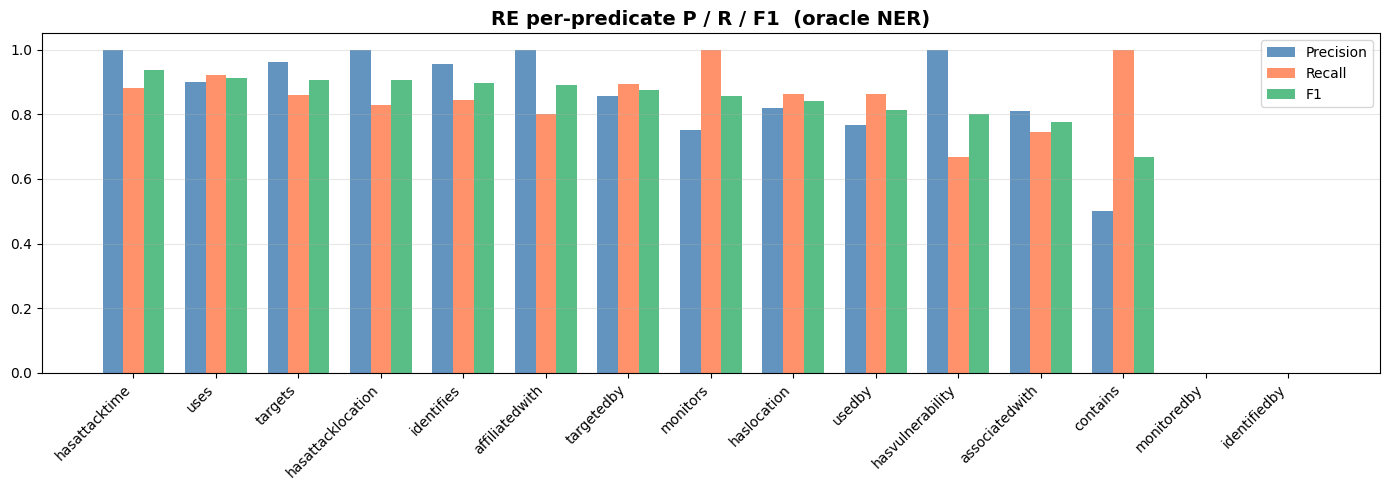

In [7]:
if re:
    preds = df_re.index.tolist()
    x, w = np.arange(len(preds)), 0.25
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - w, df_re["P"],  w, label="Precision", color="steelblue",      alpha=0.85)
    ax.bar(x,     df_re["R"],  w, label="Recall",    color="coral",           alpha=0.85)
    ax.bar(x + w, df_re["F1"], w, label="F1",        color="mediumseagreen",  alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(preds, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title("RE per-predicate P / R / F1  (oracle NER)", fontsize=14, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

## Summary

In [8]:
rows = []
for label, data in [("NER", ner), ("RE â€” oracle NER", re)]:
    if data:
        m, mm = data["micro"], data["macro"]
        rows.append({"Task": label,
                     "Micro P":  m["precision"],  "Micro R":  m["recall"],  "Micro F1":  m["f1"],
                     "Macro P": mm["precision"],  "Macro R": mm["recall"],  "Macro F1": mm["f1"]})

df_summary = pd.DataFrame(rows).set_index("Task")
display(df_summary.style
        .format("{:.4f}")
        .background_gradient(subset=["Micro F1", "Macro F1"], cmap="RdYlGn"))

,Micro P,Micro R,Micro F1,Macro P,Macro R,Macro F1
Task,,,,,,
NER,0.7383,0.7760,0.7567,0.7548,0.7794,0.7501
RE â€” oracle NER,0.8978,0.8687,0.8830,0.8978,0.9001,0.8881
